<a href="https://colab.research.google.com/github/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/KNN_AdaBoost_Bayes_y_otros_clasificadores_datos_felicidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contexto

El caso de estudio analiza y construye modelos de clasificación con datos relacionados con felicidad de personas o estudiantes de nivel superior a partir de características sociodemográficas de cada uno de ellos.

Los datos se encuentran en el enlace de github.com en el espacio del autor: https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/dataset_felicidad_estudiantes_mexico_3000.csv .

Este caso de estudio se puede ver de manera digital el el servicio *google collab* en https://colab.research.google.com/drive/1hTRQ9Cj4hc6T1xOIw4QxQHGTksKsUEjv?usp=sharing .

De igual forma el caso de estudio se encuentra en *github.com* en https://github.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/KNN_AdaBoost_Bayes_y_otros_clasificadores_datos_felicidad.ipynb .


La estructura de los datos se compone de tres mil registos y 13 variables de las cuales estas son las variables independientes:

* *edad* que implica la edad del estudiante (años),
* *salud* es la percepción del estado general de salud en una escala de 1 a 10,
* *sueno* la calidad del sueño en una escala de 1 a 10,                                        
* *estres* almacena el nivel de estrés académico percibido en una escala de 1 a 10,    
* *ingreso* es el nivel de ingreso económico personal o familiar en una escala de 1 a 10,
* *relaciones* la calidad de las relaciones sociales y familiares en una escala de 1 a 10,             
* *recreacion* la frecuencia con la que participa en actividades recreativas, en una escala de 1 a 10,
* *promedio* el promedio académico del estudiante (0–100),
* *actividad_fisica* el nivel de actividad física semanal en una escala de 1 a 10,
* *estudio* son las horas promedio dedicadas al estudio por semana,
* *autoestima* es el nivel de autoestima percibido en una escala de 1 a 10,
* *optimismo* es el nivel de optimismo frente al futuro en una escala de 1 a 10,

La variable dependiente es *felicidad* es categórica y tiene tres valores de acuerdo a nivel de felicidad:

* 0 = Baja felicidad
* 1 = Felicidad media
* 2 = Alta felicidad

El caso de estudio contiene y manda llamar funciones que se encuentra en el enlace de *github.com* en el espacio del autor: **PENDIENTE**




# Objetivo

Construir modelos de clasificación *KNN*, *Ada Boost* y *Bayes* con datos de felicidad de personas para comparar y evaluar la calidad predictiva y de clasificación de estos modelos contra otros modelos de clasificación.

# Descripción

Se sigue la metodología y estructura de los anteriores casos de estudio y que fue descrita en el capítulo tres.

## Cargar librerías

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.preprocessing import PolynomialFeatures
# from sklearn.linear_model import LinearRegression
# from sklearn.linear_model import LassoCV
# from sklearn.linear_model import RidgeCV
# from sklearn.metrics import ( mean_squared_error,
#    mean_absolute_error,  r2_score )

# from scipy.stats import shapiro
# from scipy.stats import kstest
# from statsmodels.stats.diagnostic import het_breuschpagan
# from statsmodels.stats.stattools import durbin_watson
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# from statsmodels.stats.diagnostic import linear_reset
# import statsmodels.api as sm

# Para validar posutalados
# from statsmodels.stats.outliers_influence import (
#    variance_inflation_factor)
# from statsmodels.stats.diagnostic import (het_breuschpagan,
#    linear_reset)
# from statsmodels.stats.stattools import ( durbin_watson)
# from scipy.stats import ( shapiro)
# from scipy.stats import shapiro
# from scipy.stats import kstest
# from scipy.stats import anderson
# from sklearn.linear_model import (  LassoCV)
# from sklearn.linear_model import (  RidgeCV)
# from sklearn.preprocessing import (PolynomialFeatures)
# from sklearn.svm import SVR # Para modelos SVR

from sklearn.svm import LinearSVC # Kernel lineal
from sklearn.svm import SVC # Para SVM
# Para arboles de clasificación y bosques aleatorios
from sklearn.tree import DecisionTreeClassifier # Árbol de clasificación
from sklearn.ensemble import RandomForestClassifier # Bosque aleatorio de clasificación
from sklearn.tree import plot_tree # Visualización del árbol
from sklearn.tree import export_text # Exportar reglas del árbol

from sklearn.linear_model import LogisticRegression # Reg Logistica
from sklearn.utils import resample # Muestras y submuestras

from sklearn.pipeline import Pipeline              #
from sklearn.preprocessing import StandardScaler   # Escalar en caso
from sklearn.neighbors import KNeighborsClassifier # KNN

from sklearn.ensemble import AdaBoostClassifier   # Ada Boost
from sklearn.naive_bayes import GaussianNB        # Bayes


## Cargar funciones


In [50]:
# Funciones para implementar y evaluar modelos árboles y bosques aleatorios
# como modelos de clasifgicación

# Permite construir modelos de clasificación
# SVM varios kermels
# Bosques aleatorios
# Arboles
# de regresión logística Python

# Rubén Pizarro Gurrola
# Junio 2026

#========================================================
# CARGAR DATOS
#========================================================

def f_cargar_datos(ruta_archivo):

    datos = pd.read_csv(ruta_archivo)

    return datos

#=========================================================
# FUNCIÓN
# f_redondear()
#
# ACEPTA:
# - datos (DataFrame)
#
# DEVUELVE:
# - DataFrame con las variables numéricas
#   redondeadas a dos decimales
#=========================================================

import pandas as pd
import numpy as np

def f_redondear(datos):
    """
    Redondea a dos posiciones decimales únicamente
    las variables numéricas de un DataFrame.

    Parámetros
    ----------
    datos : pandas.DataFrame

    Devuelve
    --------
    pandas.DataFrame
    """

    #---------------------------------------------
    # VALIDACIONES
    #---------------------------------------------

    if not isinstance(datos, pd.DataFrame):
        raise TypeError(
            "datos debe ser un DataFrame de pandas."
        )

    #---------------------------------------------
    # COPIA
    #---------------------------------------------

    datos_redondeados = datos.copy()

    #---------------------------------------------
    # VARIABLES NUMÉRICAS
    #---------------------------------------------

    columnas_numericas = datos_redondeados.select_dtypes(
        include=[np.number]
    ).columns

    #---------------------------------------------
    # REDONDEAR
    #---------------------------------------------

    datos_redondeados[columnas_numericas] = (
        datos_redondeados[columnas_numericas]
        .round(2)
    )

    return datos_redondeados

#========================================================
# VISUALIZAR HEAD Y TAIL
#========================================================

def f_visualizar_head_tail_reducido(
        datos,
        n = 6
):

    #----------------------------------------------------
    # Total columnas
    #----------------------------------------------------

    total_columnas = datos.shape[1]

    #----------------------------------------------------
    # Primeras 4 columnas
    #----------------------------------------------------

    idx_prim = list(
        range(
            min(4, total_columnas)
        )
    )

    #----------------------------------------------------
    # Últimas 4 columnas
    #----------------------------------------------------

    idx_ult = list(
        range(
            max(total_columnas - 4, 0),
            total_columnas
        )
    )

    #----------------------------------------------------
    # Evitar duplicados
    #----------------------------------------------------

    idx_ult = [
        i for i in idx_ult
        if i not in idx_prim
    ]

    #----------------------------------------------------
    # Subconjuntos
    #----------------------------------------------------

    datos_prim = datos.iloc[:, idx_prim]

    datos_ult = datos.iloc[:, idx_ult]

    #----------------------------------------------------
    # HEAD
    #----------------------------------------------------

    head_prim = (
        datos_prim
        .head(n)
        .astype(str)
        .reset_index(drop = True)
    )

    head_ult = (
        datos_ult
        .head(n)
        .astype(str)
        .reset_index(drop = True)
    )

    #----------------------------------------------------
    # TAIL
    #----------------------------------------------------

    tail_prim = (
        datos_prim
        .tail(n)
        .astype(str)
        .reset_index(drop = True)
    )

    tail_ult = (
        datos_ult
        .tail(n)
        .astype(str)
        .reset_index(drop = True)
    )

    #----------------------------------------------------
    # Separadores
    #----------------------------------------------------

    sep_head = pd.DataFrame({
        "...": ["..."] * n
    })

    sep_tail = pd.DataFrame({
        "...": ["..."] * n
    })

    #----------------------------------------------------
    # Combinar HEAD
    #----------------------------------------------------

    head_comb = pd.concat(

        [
            head_prim,
            sep_head,
            head_ult
        ],

        axis = 1
    )

    #----------------------------------------------------
    # Combinar TAIL
    #----------------------------------------------------

    tail_comb = pd.concat(

        [
            tail_prim,
            sep_tail,
            tail_ult
        ],

        axis = 1
    )

    #----------------------------------------------------
    # Fila separadora
    #----------------------------------------------------

    fila_sep = pd.DataFrame(

        [["..."] * head_comb.shape[1]],

        columns = head_comb.columns
    )

    #----------------------------------------------------
    # Tabla final
    #----------------------------------------------------

    tabla = pd.concat(

        [
            head_comb,
            fila_sep,
            tail_comb
        ],

        ignore_index = True
    )

    return tabla

#========================================================
# DESCRIBIR DATOS
#========================================================

#========================================================
# FUNCIÓN
# f_describir_datos()
#========================================================

def f_describir_datos(datos):

    import pandas as pd

    #----------------------------------------------------
    # ESTRUCTURA
    #----------------------------------------------------

    estructura = datos.dtypes

    #----------------------------------------------------
    # VARIABLES NUMÉRICAS
    #----------------------------------------------------

    variables_numericas = datos.select_dtypes(
        include=["number"]
    )

    describe_numericas = None

    if variables_numericas.shape[1] > 0:

        describe_numericas = (
            variables_numericas
            .describe()
            .T
            .round(4)
        )

    #----------------------------------------------------
    # VARIABLES CATEGÓRICAS
    #----------------------------------------------------

    variables_categoricas = datos.select_dtypes(
        include=["object", "category"]
    )

    frecuencias = {}

    for variable in variables_categoricas.columns:

        tabla = pd.DataFrame({

            "Frecuencia":
                datos[variable]
                .value_counts(),

            "Porcentaje":
                round(
                    datos[variable]
                    .value_counts(normalize=True)
                    * 100,
                    2
                )

        })

        frecuencias[variable] = tabla

    #----------------------------------------------------
    # RESULTADO
    #----------------------------------------------------

    return {
        "describe": describe_numericas,
        "frecuencias": frecuencias,
        "structure": estructura
    }



def f_convertir_categorias(datos):

    datos = datos.copy()

    if "felicidad" in datos.columns:

        datos["felicidad"] = (
            datos["felicidad"]
            .replace({
                0:"Baja",
                1:"Media",
                2:"Alta"
            })
        )

    return datos

#=========================================================
# FUNCIÓN
# f_frecuencias_clases()
#=========================================================

def f_frecuencias_clases(
        datos,
        ncols = 1,
        figsize = (18, 12),
        hspace = 0.60,
        wspace = 0.30):

    """
    Genera diagramas de barras para todas las variables
    categóricas (object, category y bool).

    Argumentos:
    ------------------------------------------------------
    datos    : DataFrame
    ncols    : Número de columnas del grid
    figsize  : Tamaño de la figura
    hspace   : Espacio vertical entre filas
    wspace   : Espacio horizontal entre columnas
    """

    #-----------------------------------------------------
    # LIBRERÍAS
    #-----------------------------------------------------

    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    #-----------------------------------------------------
    # VARIABLES CATEGÓRICAS
    #-----------------------------------------------------

    variables = datos.select_dtypes(
        include=[
            "object",
            "category",
            "bool"
        ]
    ).columns.tolist()

    if len(variables) == 0:

        print(
            "No existen variables categóricas en el conjunto de datos."
        )

        return

    #-----------------------------------------------------
    # GRID
    #-----------------------------------------------------

    nvars = len(variables)

    nrows = int(
        np.ceil(
            nvars / ncols
        )
    )

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize = figsize
    )

    #-----------------------------------------------------
    # ASEGURAR VECTOR DE EJES
    #-----------------------------------------------------

    if nvars == 1:

        axes = np.array([axes])

    else:

        axes = np.array(axes).reshape(-1)

    #-----------------------------------------------------
    # GRÁFICOS
    #-----------------------------------------------------

    for i, variable in enumerate(variables):

        frecuencias = (
            datos[variable]
            .value_counts(dropna = False)
        )

        frecuencias.plot(
            kind = "bar",
            ax = axes[i]
        )

        #-------------------------------------------------
        # TÍTULO
        #-------------------------------------------------

        axes[i].set_title(
            variable,
            fontsize = 11,
            pad = 12
        )

        axes[i].set_xlabel("")

        axes[i].set_ylabel(
            "Frecuencia"
        )

        #-------------------------------------------------
        # ROTACIÓN ETIQUETAS
        #-------------------------------------------------

        axes[i].tick_params(
            axis = "x",
            rotation = 45,
            labelsize = 8
        )

        #-------------------------------------------------
        # ETIQUETAS SOBRE BARRAS
        #-------------------------------------------------

        for barra in axes[i].patches:

            altura = barra.get_height()

            axes[i].annotate(

                f"{int(altura):,}",

                (
                    barra.get_x() +
                    barra.get_width()/2,
                    altura
                ),

                ha = "center",

                va = "bottom",

                fontsize = 8

            )

    #-----------------------------------------------------
    # ELIMINAR EJES SOBRANTES
    #-----------------------------------------------------

    for j in range(
        len(variables),
        len(axes)
    ):

        fig.delaxes(
            axes[j]
        )

    #-----------------------------------------------------
    # ESPACIADO
    #-----------------------------------------------------

    plt.subplots_adjust(

        hspace = hspace,

        wspace = wspace

    )

    plt.tight_layout(
        pad = 2.5
    )

    plt.show()


def f_estandarizar_escalar(datos,
                           decimales = 4):

    datos_est = datos.copy()
    datos_esc = datos.copy()

    columnas_num = datos.select_dtypes(include = np.number).columns

    scaler_est = StandardScaler()

    scaler_minmax = MinMaxScaler()

    datos_est[columnas_num] = np.round(
        scaler_est.fit_transform(datos[columnas_num]),
        decimales
    )

    datos_esc[columnas_num] = np.round(
        scaler_minmax.fit_transform(datos[columnas_num]),
        decimales
    )

    return {
        "datos_estandarizados": datos_est,
        "datos_escalados": datos_esc
    }

#=========================================================
# FUNCIÓN
# f_crear_modelo_KNN()
#=========================================================

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

import pandas as pd

def f_crear_modelo_KNN(
    datos_entrenamiento,
    variable_dependiente,
    k=5,
    escalar=False
):
    """
    Construye un modelo de clasificación KNN.

    Parámetros
    ----------
    datos_entrenamiento : DataFrame
    variable_dependiente : str
    k : int
    escalar : bool

    Devuelve
    --------
    modelo : Pipeline o KNeighborsClassifier
    """

    #-----------------------------------------------------
    # VALIDACIONES
    #-----------------------------------------------------

    if not isinstance(datos_entrenamiento, pd.DataFrame):

        raise TypeError(
            "datos_entrenamiento debe ser un DataFrame."
        )

    if variable_dependiente not in datos_entrenamiento.columns:

        raise ValueError(
            f"La variable '{variable_dependiente}' no existe."
        )

    if k <= 0:

        raise ValueError(
            "k debe ser mayor que cero."
        )

    #-----------------------------------------------------
    # VARIABLES
    #-----------------------------------------------------

    X = datos_entrenamiento.drop(
        columns=[variable_dependiente]
    )

    y = datos_entrenamiento[
        variable_dependiente
    ]

    #-----------------------------------------------------
    # VALIDAR VARIABLES NUMÉRICAS
    #-----------------------------------------------------

    if not all(
        X.dtypes.apply(
            lambda x: x.kind in "if"
        )
    ):

        raise ValueError(

            "Todas las variables predictoras deben ser numéricas."

        )

    #-----------------------------------------------------
    # MODELO
    #-----------------------------------------------------

    if escalar:

        modelo = Pipeline([

            ("escalador",
             StandardScaler()),

            ("knn",
             KNeighborsClassifier(
                 n_neighbors=k
             ))

        ])

    else:

        modelo = KNeighborsClassifier(
            n_neighbors=k
        )

    #-----------------------------------------------------
    # ENTRENAMIENTO
    #-----------------------------------------------------

    modelo.fit(X, y)

    #-----------------------------------------------------
    # INFORMACIÓN
    #-----------------------------------------------------

    print()

    print("---------------------------------------")

    print("Modelo KNN construido correctamente")

    print("---------------------------------------")

    print(f"Observaciones : {X.shape[0]}")

    print(f"Variables     : {X.shape[1]}")

    print(f"k             : {k}")

    print(f"Escalamiento  : {escalar}")

    print("---------------------------------------")

    print()

    return modelo

#=========================================================
# FUNCIÓN
# f_crear_modelo_Ada_Boost()
#=========================================================

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

def f_crear_modelo_Ada_Boost(
    datos_entrenamiento,
    variable_dependiente,
    n_estimators=50,
    learning_rate=1.0,
    random_state=123
):
    """
    Construye un modelo de clasificación AdaBoost.

    Parámetros
    ----------
    datos_entrenamiento : DataFrame
    variable_dependiente : str
    n_estimators : int
    learning_rate : float
    random_state : int

    Devuelve
    --------
    modelo : AdaBoostClassifier
    """

    #-----------------------------------------------------
    # VALIDACIONES
    #-----------------------------------------------------

    if not isinstance(datos_entrenamiento, pd.DataFrame):

        raise TypeError(
            "datos_entrenamiento debe ser un DataFrame."
        )

    if variable_dependiente not in datos_entrenamiento.columns:

        raise ValueError(
            f"La variable '{variable_dependiente}' no existe."
        )

    if n_estimators <= 0:

        raise ValueError(
            "n_estimators debe ser mayor que cero."
        )

    #-----------------------------------------------------
    # VARIABLES
    #-----------------------------------------------------

    X = datos_entrenamiento.drop(
        columns=[variable_dependiente]
    )

    y = datos_entrenamiento[
        variable_dependiente
    ]

    #-----------------------------------------------------
    # VALIDAR VARIABLES NUMÉRICAS
    #-----------------------------------------------------

    if not all(
        X.dtypes.apply(
            lambda x: x.kind in "if"
        )
    ):

        raise ValueError(
            "Todas las variables predictoras deben ser numéricas."
        )

    #-----------------------------------------------------
    # CLASIFICADOR BASE
    #-----------------------------------------------------

    clasificador_base = DecisionTreeClassifier(
        max_depth=1,
        random_state=random_state
    )

    #-----------------------------------------------------
    # MODELO
    #-----------------------------------------------------

    modelo = AdaBoostClassifier(

        estimator=clasificador_base,

        n_estimators=n_estimators,

        learning_rate=learning_rate,

        random_state=random_state

    )

    #-----------------------------------------------------
    # ENTRENAMIENTO
    #-----------------------------------------------------

    modelo.fit(X, y)

    #-----------------------------------------------------
    # INFORMACIÓN
    #-----------------------------------------------------

    print()

    print("---------------------------------------")

    print("Modelo AdaBoost construido correctamente")

    print("---------------------------------------")

    print(f"Observaciones : {X.shape[0]}")

    print(f"Variables     : {X.shape[1]}")

    print(f"Clasificadores: {n_estimators}")

    print(f"Learning Rate : {learning_rate}")

    print(f"Random State  : {random_state}")

    print("---------------------------------------")

    print()

    return modelo


#=========================================================
# FUNCIÓN
# f_crear_modelo_Bayes()
#=========================================================

from sklearn.naive_bayes import GaussianNB
import pandas as pd

def f_crear_modelo_Bayes(
    datos_entrenamiento,
    variable_dependiente
):
    """
    Construye un modelo de clasificación
    Naïve Bayes Gaussiano.

    Parámetros
    ----------
    datos_entrenamiento : DataFrame
    variable_dependiente : str

    Devuelve
    --------
    modelo : GaussianNB
    """

    #-----------------------------------------------------
    # VALIDACIONES
    #-----------------------------------------------------

    if not isinstance(datos_entrenamiento, pd.DataFrame):

        raise TypeError(
            "datos_entrenamiento debe ser un DataFrame."
        )

    if variable_dependiente not in datos_entrenamiento.columns:

        raise ValueError(
            f"La variable '{variable_dependiente}' no existe."
        )

    #-----------------------------------------------------
    # VARIABLES
    #-----------------------------------------------------

    X = datos_entrenamiento.drop(
        columns=[variable_dependiente]
    )

    y = datos_entrenamiento[
        variable_dependiente
    ]

    #-----------------------------------------------------
    # VALIDAR VARIABLES NUMÉRICAS
    #-----------------------------------------------------

    if not all(
        X.dtypes.apply(
            lambda x: x.kind in "if"
        )
    ):

        raise ValueError(
            "GaussianNB requiere variables predictoras numéricas."
        )

    #-----------------------------------------------------
    # MODELO
    #-----------------------------------------------------

    modelo = GaussianNB()

    #-----------------------------------------------------
    # ENTRENAMIENTO
    #-----------------------------------------------------

    modelo.fit(X, y)

    #-----------------------------------------------------
    # INFORMACIÓN
    #-----------------------------------------------------

    print()

    print("---------------------------------------")

    print("Modelo Naïve Bayes construido correctamente")

    print("---------------------------------------")

    print(f"Observaciones : {X.shape[0]}")

    print(f"Variables     : {X.shape[1]}")

    print(f"Clases        : {len(pd.unique(y))}")

    print("---------------------------------------")

    print()

    return modelo

#=========================================================
# FUNCIÓN
# f_crear_modelo_SVM_lineal()
#
# ACEPTA:
# - datos
# - variable_dependiente
# - C = 0.1
#
# DEVUELVE:
# - modelo SVM Lineal
#=========================================================

import pandas as pd

from sklearn.svm import SVC


#=========================================================
# FUNCIÓN
# f_crear_modelo_SVM_lineal()
#
# ACEPTA:
# - datos
# - variable_dependiente
# - C = 0.1
#
# DEVUELVE:
# - modelo SVM Lineal
#=========================================================

import pandas as pd
import numpy as np

from sklearn.svm import LinearSVC


def f_crear_modelo_SVM_lineal(
        datos,
        variable_dependiente,
        C=0.1):
    """
    Construye un modelo SVM con kernel lineal.

    Parámetros
    ----------
    datos : pandas.DataFrame

    variable_dependiente : str

    C : float, default=0.1

    Devuelve
    --------
    modelo : LinearSVC
    """

    #------------------------------------------------------
    # VALIDACIONES
    #------------------------------------------------------

    if not isinstance(datos, pd.DataFrame):

        raise TypeError(
            "datos debe ser un DataFrame de pandas."
        )

    if variable_dependiente not in datos.columns:

        raise ValueError(
            f"La variable '{variable_dependiente}' "
            "no existe en los datos."
        )

    #------------------------------------------------------
    # VARIABLES INDEPENDIENTES
    #------------------------------------------------------

    X = datos.drop(
        columns=[variable_dependiente]
    )

    y = datos[
        variable_dependiente
    ]

    #------------------------------------------------------
    # VALIDAR VARIABLES NUMÉRICAS
    #------------------------------------------------------

    if not np.all(
        [np.issubdtype(t, np.number)
         for t in X.dtypes]
    ):

        raise ValueError(
            "Todas las variables independientes "
            "deben ser numéricas."
        )

    #------------------------------------------------------
    # MODELO
    #------------------------------------------------------

    modelo_SVM = LinearSVC(

        C=C,

        dual="auto",

        random_state=123,

        max_iter=10000

    )

    modelo_SVM.fit(X, y)

    #------------------------------------------------------
    # INFORMACIÓN
    #------------------------------------------------------

    print("\n======================================")
    print("MODELO SVM LINEAL")
    print("======================================")
    print(f"Kernel              : Lineal")
    print(f"Implementación      : LinearSVC (LIBLINEAR)")
    print(f"Cost (C)            : {C}")
    print(f"Número de clases    : {len(modelo_SVM.classes_)}")
    print(f"Iteraciones         : {modelo_SVM.n_iter_}")
    print("======================================\n")

    return modelo_SVM

#=========================================================
# FUNCIÓN
# f_crear_modelo_SVM_polinomial()
#
# ACEPTA:
# - datos
# - variable_dependiente
# - grado = 2
# - C = 0.1
# - coef0 = 1
#
# DEVUELVE:
# - modelo SVM Polinomial
#=========================================================

import pandas as pd
import numpy as np

from sklearn.svm import SVC


def f_crear_modelo_SVM_polinomial(
        datos,
        variable_dependiente,
        grado=2,
        C=0.1,
        coef0=1):

    """
    Construye un modelo SVM con kernel polinomial.

    Parámetros
    ----------
    datos : pandas.DataFrame

    variable_dependiente : str

    grado : int, default=2

    C : float, default=0.1

    coef0 : float, default=1

    Devuelve
    --------
    modelo : sklearn.svm.SVC
    """

    #------------------------------------------------------
    # VALIDACIONES
    #------------------------------------------------------

    if not isinstance(datos, pd.DataFrame):

        raise TypeError(
            "datos debe ser un DataFrame de pandas."
        )

    if variable_dependiente not in datos.columns:

        raise ValueError(
            f"La variable '{variable_dependiente}' "
            "no existe en los datos."
        )

    #------------------------------------------------------
    # VARIABLES
    #------------------------------------------------------

    X = datos.drop(
        columns=[variable_dependiente]
    )

    y = datos[
        variable_dependiente
    ]

    #------------------------------------------------------
    # VALIDAR VARIABLES NUMÉRICAS
    #------------------------------------------------------

    if not np.all(
        [np.issubdtype(t, np.number)
         for t in X.dtypes]
    ):

        raise ValueError(
            "Todas las variables independientes "
            "deben ser numéricas."
        )

    #------------------------------------------------------
    # MODELO
    #------------------------------------------------------

    modelo_SVM = SVC(

        kernel="poly",

        degree=grado,

        C=C,

        coef0=coef0,

        gamma="scale",

        probability=True,

        random_state=123

    )

    modelo_SVM.fit(X, y)

    #------------------------------------------------------
    # INFORMACIÓN
    #------------------------------------------------------

    print("\n========================================")
    print("MODELO SVM POLINOMIAL")
    print("========================================")
    print(f"Kernel               : Polinomial")
    print(f"Grado                : {grado}")
    print(f"Cost (C)             : {C}")
    print(f"Coef0                : {coef0}")
    print(f"Gamma                : scale")
    print(f"Número de clases     : {len(modelo_SVM.classes_)}")
    print(f"Vectores de soporte  : {modelo_SVM.support_vectors_.shape[0]}")
    print("========================================\n")

    return modelo_SVM

#=========================================================
# FUNCIÓN
# f_crear_modelo_SVM_radial()
#
# ACEPTA:
# - datos
# - variable_dependiente
# - C = 0.1
# - gamma = "scale"
#
# DEVUELVE:
# - modelo SVM Radial
#=========================================================

import pandas as pd
import numpy as np

from sklearn.svm import SVC


def f_crear_modelo_SVM_radial(
        datos,
        variable_dependiente,
        C=0.1,
        gamma="scale"):

    """
    Construye un modelo SVM con kernel radial (RBF).

    Parámetros
    ----------
    datos : pandas.DataFrame

    variable_dependiente : str

    C : float, default=0.1

    gamma : {"scale","auto"} o float,
            default="scale"

    Devuelve
    --------
    modelo : sklearn.svm.SVC
    """

    #------------------------------------------------------
    # VALIDACIONES
    #------------------------------------------------------

    if not isinstance(datos, pd.DataFrame):

        raise TypeError(
            "datos debe ser un DataFrame de pandas."
        )

    if variable_dependiente not in datos.columns:

        raise ValueError(
            f"La variable '{variable_dependiente}' "
            "no existe en los datos."
        )

    #------------------------------------------------------
    # VARIABLES
    #------------------------------------------------------

    X = datos.drop(
        columns=[variable_dependiente]
    )

    y = datos[
        variable_dependiente
    ]

    #------------------------------------------------------
    # VALIDAR VARIABLES NUMÉRICAS
    #------------------------------------------------------

    if not np.all(
        [np.issubdtype(t, np.number)
         for t in X.dtypes]
    ):

        raise ValueError(
            "Todas las variables independientes "
            "deben ser numéricas."
        )

    #------------------------------------------------------
    # MODELO
    #------------------------------------------------------

    modelo_SVM = SVC(

        kernel="rbf",

        C=C,

        gamma=gamma,

        probability=True,

        random_state=123

    )

    modelo_SVM.fit(X, y)

    #------------------------------------------------------
    # INFORMACIÓN
    #------------------------------------------------------

    print("\n========================================")
    print("MODELO SVM RADIAL")
    print("========================================")
    print(f"Kernel               : Radial (RBF)")
    print(f"Cost (C)             : {C}")
    print(f"Gamma                : {gamma}")
    print(f"Número de clases     : {len(modelo_SVM.classes_)}")
    print(f"Vectores de soporte  : {modelo_SVM.support_vectors_.shape[0]}")
    print("========================================\n")

    return modelo_SVM

#=========================================================
# FUNCIÓN
# f_convertir_dummys()
#=========================================================

def f_convertir_dummys(datos):

    """
    Convierte automáticamente todas las variables
    categóricas (object, category y bool)
    en variables dummy.

    Argumentos
    ----------
    datos : DataFrame

    Retorna
    -------
    DataFrame con variables dummy
    """

    import pandas as pd

    #-----------------------------------------------------
    # COPIA
    #-----------------------------------------------------

    datos_dummys = datos.copy()

    #-----------------------------------------------------
    # VARIABLES CATEGÓRICAS
    #-----------------------------------------------------

    variables_categoricas = (
        datos_dummys
        .select_dtypes(
            include=[
                "object",
                "category",
                "bool"
            ]
        )
        .columns
    )

    #-----------------------------------------------------
    # DUMMIES
    #-----------------------------------------------------

    datos_dummys = pd.get_dummies(

        datos_dummys,

        columns = variables_categoricas,

        drop_first = True,

        dtype = int

    )

    #-----------------------------------------------------
    # INFORMACIÓN
    #-----------------------------------------------------

    print()

    print("="*40)

    print(" CONVERSIÓN A VARIABLES DUMMY ")

    print("="*40)

    print(
        "Variables originales :",
        datos.shape[1]
    )

    print(
        "Variables finales    :",
        datos_dummys.shape[1]
    )

    print(
        "Observaciones        :",
        datos_dummys.shape[0]
    )

    print("="*40)

    return datos_dummys

def f_particionar_datos(datos,
                         proporcion_entrenamiento = 0.7):

    datos_entrenamiento, datos_validacion = train_test_split(
        datos,
        train_size = proporcion_entrenamiento,
        random_state = 2026
    )

    return {
        "datos_entrenamiento": datos_entrenamiento,
        "datos_validacion": datos_validacion
    }

#=========================================================
# FUNCIÓN
# f_construir_arbol_clasificacion()
#=========================================================

def f_construir_arbol_clasificacion(
        datos,
        variable_dependiente,
        criterion="gini",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=123):

    #-----------------------------------------------------
    # LIBRERÍAS
    #-----------------------------------------------------

    import pandas as pd

    from sklearn.tree import DecisionTreeClassifier

    #-----------------------------------------------------
    # VALIDACIONES
    #-----------------------------------------------------

    if variable_dependiente not in datos.columns:

        raise ValueError(
            f"La variable '{variable_dependiente}' no existe."
        )

    #-----------------------------------------------------
    # X e y
    #-----------------------------------------------------

    X = datos.drop(
        columns=[variable_dependiente]
    )

    y = datos[
        variable_dependiente
    ]

    #-----------------------------------------------------
    # MODELO
    #-----------------------------------------------------

    modelo = DecisionTreeClassifier(

        criterion=criterion,

        max_depth=max_depth,

        min_samples_split=min_samples_split,

        min_samples_leaf=min_samples_leaf,

        random_state=random_state
    )

    modelo.fit(X, y)

    #-----------------------------------------------------
    # METADATOS
    #-----------------------------------------------------

    modelo.variable_dependiente = variable_dependiente

    modelo.n_clases = y.nunique()

    modelo.clases = list(y.unique())

    modelo.frecuencias_clases = (
        y.value_counts()
        .sort_index()
        .to_dict()
    )

    modelo.n_variables = X.shape[1]

    #-----------------------------------------------------
    # RESUMEN
    #-----------------------------------------------------

    print()
    print("====================================")
    print(" ÁRBOL DE CLASIFICACIÓN")
    print("====================================")
    print("Variable objetivo :", variable_dependiente)
    print("Número clases     :", modelo.n_clases)
    print("Variables         :", modelo.n_variables)
    print("Criterio          :", criterion)
    print("Observaciones     :", len(datos))
    print()

    print("Frecuencia de clases")

    for k, v in modelo.frecuencias_clases.items():

        print(f"{k}: {v}")

    print("====================================")

    return modelo


#=========================================================
# FUNCIÓN
# f_visualizar_arbol()
#=========================================================

def f_visualizar_arbol(
        modelo,
        figsize=(22,12),
        profunidad=3,
        fontsize=9):

    #-----------------------------------------------------
    # LIBRERÍAS
    #-----------------------------------------------------

    import matplotlib.pyplot as plt

    from sklearn.tree import plot_tree

    from sklearn.tree import DecisionTreeClassifier

    #-----------------------------------------------------
    # VALIDACIÓN
    #-----------------------------------------------------

    if not isinstance(
        modelo,
        DecisionTreeClassifier
    ):

        raise ValueError(
            "El modelo debe ser DecisionTreeClassifier."
        )

    #-----------------------------------------------------
    # FIGURA
    #-----------------------------------------------------

    plt.figure(
        figsize=figsize
    )

    plot_tree(

        modelo,

        filled=True,

        rounded=True,

        feature_names=modelo.feature_names_in_,

        class_names=[
            str(x)
            for x in modelo.classes_
        ],

        max_depth=profunidad,

        fontsize=fontsize
    )

    plt.title(
        "Árbol de Clasificación"
    )

    plt.show()


#=========================================================
# FUNCIÓN
# f_variables_importantes()
#=========================================================

def f_variables_importantes(
        modelos,
        nombres_modelos=None,
        top=10,
        ncols=2,
        figsize=(14,8)):

    #-----------------------------------------------------
    # LIBRERÍAS
    #-----------------------------------------------------

    import pandas as pd
    import matplotlib.pyplot as plt
    import math

    #-----------------------------------------------------
    # CONVERTIR A LISTA
    #-----------------------------------------------------

    if not isinstance(modelos, list):

        modelos = [modelos]

    #-----------------------------------------------------
    # NOMBRES
    #-----------------------------------------------------

    if nombres_modelos is None:

        nombres_modelos = [

            f"Modelo {i+1}"

            for i in range(
                len(modelos)
            )
        ]

    #-----------------------------------------------------
    # GRID
    #-----------------------------------------------------

    n_modelos = len(modelos)

    nrows = math.ceil(
        n_modelos / ncols
    )

    fig, axes = plt.subplots(

        nrows=nrows,

        ncols=ncols,

        figsize=figsize

    )

    #-----------------------------------------------------
    # AJUSTAR AXES
    #-----------------------------------------------------

    if n_modelos == 1:

        axes = [axes]

    else:

        axes = axes.flatten()

    #-----------------------------------------------------
    # TABLA GLOBAL
    #-----------------------------------------------------

    tabla_global = []

    #-----------------------------------------------------
    # RECORRER MODELOS
    #-----------------------------------------------------

    for i, modelo in enumerate(modelos):

        importancia = pd.DataFrame({

            "Variable":
                modelo.feature_names_in_,

            "Importancia":
                modelo.feature_importances_

        })

        #---------------------------------------------
        # PORCENTAJE
        #---------------------------------------------

        importancia["Importancia"] = (

            importancia["Importancia"]

            * 100

        )

        importancia = (

            importancia

            .sort_values(

                by="Importancia",

                ascending=False

            )

            .head(top)

            .reset_index(drop=True)

        )

        #---------------------------------------------
        # REDONDEAR
        #---------------------------------------------

        importancia["Importancia"] = (

            importancia["Importancia"]

            .round(2)

        )

        importancia["Modelo"] = (

            nombres_modelos[i]

        )

        tabla_global.append(
            importancia
        )

        #---------------------------------------------
        # GRÁFICA
        #---------------------------------------------

        ax = axes[i]

        ax.barh(

            importancia["Variable"],

            importancia["Importancia"]

        )

        #---------------------------------------------
        # ETIQUETAS
        #---------------------------------------------

        for j, valor in enumerate(

            importancia["Importancia"]

        ):

            ax.text(

                valor,

                j,

                f"{valor:.2f}",

                va="center"

            )

        ax.invert_yaxis()

        ax.set_title(

            nombres_modelos[i]

        )

        ax.set_xlabel(

            "Importancia (%)"

        )

        ax.set_ylabel("")

    #-----------------------------------------------------
    # ELIMINAR EJES VACÍOS
    #-----------------------------------------------------

    for j in range(

        n_modelos,

        len(axes)

    ):

        fig.delaxes(
            axes[j]
        )

    #-----------------------------------------------------
    # AJUSTES
    #-----------------------------------------------------

    plt.tight_layout()

    plt.show()

    #-----------------------------------------------------
    # TABLA CONSOLIDADA
    #-----------------------------------------------------

    tabla_global = pd.concat(

        tabla_global,

        ignore_index=True

    )

    return tabla_global


#=========================================================
# FUNCIÓN
# f_construir_random_forest()
#=========================================================

def f_construir_random_forest(
        datos,
        variable_dependiente,
        n_estimators=500,
        criterion="gini",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        random_state=123):

    #-----------------------------------------------------
    # LIBRERÍAS
    #-----------------------------------------------------

    import pandas as pd

    from sklearn.ensemble import RandomForestClassifier

    #-----------------------------------------------------
    # VALIDACIONES
    #-----------------------------------------------------

    if variable_dependiente not in datos.columns:

        raise ValueError(
            f"La variable '{variable_dependiente}' no existe."
        )

    #-----------------------------------------------------
    # X e y
    #-----------------------------------------------------

    X = datos.drop(
        columns=[variable_dependiente]
    )

    y = datos[
        variable_dependiente
    ]

    #-----------------------------------------------------
    # MODELO
    #-----------------------------------------------------

    modelo = RandomForestClassifier(

        n_estimators=n_estimators,

        criterion=criterion,

        max_depth=max_depth,

        min_samples_split=min_samples_split,

        min_samples_leaf=min_samples_leaf,

        max_features=max_features,

        random_state=random_state,

        n_jobs=-1
    )

    modelo.fit(X, y)

    #-----------------------------------------------------
    # METADATOS
    #-----------------------------------------------------

    modelo.variable_dependiente = (
        variable_dependiente
    )

    modelo.n_clases = y.nunique()

    modelo.clases = list(
        y.unique()
    )

    modelo.frecuencias_clases = (
        y.value_counts()
         .sort_index()
         .to_dict()
    )

    modelo.n_variables = X.shape[1]

    #-----------------------------------------------------
    # RESUMEN
    #-----------------------------------------------------

    print()
    print("==================================================")
    print(" RANDOM FOREST")
    print("==================================================")

    print(
        f"Variable objetivo : {variable_dependiente}"
    )

    print(
        f"Número de clases  : {modelo.n_clases}"
    )

    print(
        f"Variables         : {modelo.n_variables}"
    )

    print(
        f"Árboles           : {n_estimators}"
    )

    print(
        f"Criterio          : {criterion}"
    )

    print(
        f"Observaciones     : {len(datos)}"
    )

    print()
    print("Frecuencias:")

    for clase, frecuencia in (
        modelo.frecuencias_clases.items()
    ):

        print(
            f"{clase}: {frecuencia}"
        )

    print("==================================================")

    return modelo




#=========================================================
# FUNCIÓN
# f_estandarizar_train_transf_valid()
#=========================================================

def f_estandarizar_train_transf_valid(
        datos_entrenamiento,
        datos_validacion,
        variable_dependiente):

    #-----------------------------------------------------
    # LIBRERÍAS
    #-----------------------------------------------------

    import pandas as pd

    from sklearn.preprocessing import StandardScaler

    #-----------------------------------------------------
    # COPIAS
    #-----------------------------------------------------

    entrenamiento = datos_entrenamiento.copy()

    validacion = datos_validacion.copy()

    #-----------------------------------------------------
    # X TRAIN
    #-----------------------------------------------------

    X_train = entrenamiento.drop(
        columns=[variable_dependiente]
    )

    y_train = entrenamiento[
        variable_dependiente
    ]

    #-----------------------------------------------------
    # X VALID
    #-----------------------------------------------------

    X_valid = validacion.drop(
        columns=[variable_dependiente]
    )

    y_valid = validacion[
        variable_dependiente
    ]

    #-----------------------------------------------------
    # ESCALADOR
    #-----------------------------------------------------

    scaler = StandardScaler()

    #-----------------------------------------------------
    # AJUSTAR SOLO TRAIN
    #-----------------------------------------------------

    X_train_std = scaler.fit_transform(
        X_train
    )

    #-----------------------------------------------------
    # TRANSFORMAR VALIDACIÓN
    #-----------------------------------------------------

    X_valid_std = scaler.transform(
        X_valid
    )

    #-----------------------------------------------------
    # DATAFRAMES
    #-----------------------------------------------------

    X_train_std = pd.DataFrame(
        X_train_std,
        columns=X_train.columns,
        index=X_train.index
    )

    X_valid_std = pd.DataFrame(
        X_valid_std,
        columns=X_valid.columns,
        index=X_valid.index
    )

    #-----------------------------------------------------
    # RECONSTRUIR DATASETS
    #-----------------------------------------------------

    datos_entrenamiento_std = pd.concat(
        [X_train_std, y_train],
        axis=1
    )

    datos_validacion_std = pd.concat(
        [X_valid_std, y_valid],
        axis=1
    )

    #-----------------------------------------------------
    # RESULTADO
    #-----------------------------------------------------

    return {

        "datos_entrenamiento":
            datos_entrenamiento_std,

        "datos_validacion":
            datos_validacion_std,

        "scaler":
            scaler

    }

#=========================================================
# FUNCIÓN
# f_crear_modelo_regresion_logistica()
#=========================================================

def f_crear_modelo_regresion_logistica(
        datos,
        variable_dependiente,
        tipo="binomial",
        balanceo="ninguno",
        semilla=123):

    #-----------------------------------------------------
    # LIBRERÍAS
    #-----------------------------------------------------

    import pandas as pd
    import numpy as np

    from sklearn.linear_model import LogisticRegression

    from sklearn.utils import resample

    #-----------------------------------------------------
    # VALIDACIONES
    #-----------------------------------------------------

    if variable_dependiente not in datos.columns:

        raise ValueError(
            f"La variable '{variable_dependiente}' no existe."
        )

    #-----------------------------------------------------
    # COPIA
    #-----------------------------------------------------

    np.random.seed(semilla)

    datos = datos.copy()

    datos_originales = datos.copy()

    #-----------------------------------------------------
    # VARIABLE DEPENDIENTE
    #-----------------------------------------------------

    y = datos[variable_dependiente]

    X = datos.drop(
        columns=[variable_dependiente]
    )

    #-----------------------------------------------------
    # FRECUENCIAS ORIGINALES
    #-----------------------------------------------------

    frecuencias_originales = (
        y
        .value_counts()
        .to_dict()
    )

    porcentajes_originales = (
        y
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .to_dict()
    )

    #-----------------------------------------------------
    # NÚMERO DE CLASES
    #-----------------------------------------------------

    n_clases = y.nunique()

    #-----------------------------------------------------
    # PONDERACIONES
    #-----------------------------------------------------

    class_weight = None

    #-----------------------------------------------------
    # BALANCEO
    #-----------------------------------------------------

    if balanceo.lower() == "undersampling":

        frecuencia_min = y.value_counts().min()

        datos_balanceados = []

        for clase in y.unique():

            temp = datos[
                datos[variable_dependiente] == clase
            ]

            temp = resample(
                temp,
                replace=False,
                n_samples=frecuencia_min,
                random_state=semilla
            )

            datos_balanceados.append(temp)

        datos = pd.concat(
            datos_balanceados,
            axis=0
        )

        datos = datos.sample(
            frac=1,
            random_state=semilla
        )

        y = datos[variable_dependiente]

        X = datos.drop(
            columns=[variable_dependiente]
        )

    #-----------------------------------------------------

    elif balanceo.lower() == "oversampling":

        frecuencia_max = y.value_counts().max()

        datos_balanceados = []

        for clase in y.unique():

            temp = datos[
                datos[variable_dependiente] == clase
            ]

            temp = resample(
                temp,
                replace=True,
                n_samples=frecuencia_max,
                random_state=semilla
            )

            datos_balanceados.append(temp)

        datos = pd.concat(
            datos_balanceados,
            axis=0
        )

        datos = datos.sample(
            frac=1,
            random_state=semilla
        )

        y = datos[variable_dependiente]

        X = datos.drop(
            columns=[variable_dependiente]
        )

    #-----------------------------------------------------

    elif balanceo.lower() == "smote":

        from imblearn.over_sampling import SMOTE

        smote = SMOTE(
            random_state=semilla
        )

        X, y = smote.fit_resample(
            X,
            y
        )

    #-----------------------------------------------------

    elif balanceo.lower() == "ponderacion":

        class_weight = "balanced"

    #-----------------------------------------------------

    elif balanceo.lower() == "ninguno":

        pass

    #-----------------------------------------------------

    else:

        raise ValueError(
            "balanceo debe ser: "
            "'ninguno', "
            "'undersampling', "
            "'oversampling', "
            "'SMOTE' o "
            "'ponderacion'"
        )

    #-----------------------------------------------------
    # FRECUENCIAS ENTRENAMIENTO
    #-----------------------------------------------------

    frecuencias_entrenamiento = (
        pd.Series(y)
        .value_counts()
        .to_dict()
    )

    porcentajes_entrenamiento = (
        pd.Series(y)
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .to_dict()
    )

    #-----------------------------------------------------
    # MODELO BINOMIAL
    #-----------------------------------------------------

    if tipo.lower() == "binomial":

        if n_clases != 2:

            raise ValueError(
                "La regresión logística binomial "
                "requiere exactamente 2 clases."
            )

        modelo = LogisticRegression(

            class_weight=class_weight,

            max_iter=5000,

            random_state=semilla

        )

    #-----------------------------------------------------
    # MODELO MULTINOMIAL
    #-----------------------------------------------------

    elif tipo.lower() == "multinomial":

        modelo = LogisticRegression(

            # multi_class="multinomial",

            solver="lbfgs",

            class_weight=class_weight,

            max_iter=3000,

            random_state=semilla

        )

    #-----------------------------------------------------

    else:

        raise ValueError(
            "tipo debe ser "
            "'binomial' o "
            "'multinomial'"
        )

    #-----------------------------------------------------
    # AJUSTE
    #-----------------------------------------------------

    modelo.fit(X, y)

    #-----------------------------------------------------
    # METADATOS
    #-----------------------------------------------------

    modelo.variable_dependiente = variable_dependiente

    modelo.tipo_modelo = tipo

    modelo.balanceo = balanceo

    modelo.n_clases = n_clases

    modelo.frecuencias_originales = frecuencias_originales

    modelo.porcentajes_originales = porcentajes_originales

    modelo.frecuencias_entrenamiento = frecuencias_entrenamiento

    modelo.porcentajes_entrenamiento = porcentajes_entrenamiento

    #-----------------------------------------------------
    # RESUMEN
    #-----------------------------------------------------

    print()

    print("="*50)

    print(" REGRESIÓN LOGÍSTICA ")

    print("="*50)

    print("Tipo               :", tipo)

    print("Balanceo           :", balanceo)

    print("Variable objetivo  :", variable_dependiente)

    print("Número de clases   :", n_clases)

    print()

    print("Frecuencias originales:")

    print(frecuencias_originales)

    print()

    print("Frecuencias entrenamiento:")

    print(frecuencias_entrenamiento)

    print()

    print("Observaciones usadas:", len(y))

    print("="*50)

    return modelo

#=========================================================
# FUNCIÓN
# f_predicciones()
#=========================================================

def f_predicciones(
        modelo,
        datos_validacion,
        variable_dependiente):

    import pandas as pd
    import numpy as np

    #-----------------------------------------------------
    # VARIABLES INDEPENDIENTES
    #-----------------------------------------------------

    X = datos_validacion.drop(
        columns=[variable_dependiente]
    )

    #-----------------------------------------------------
    # CLASES PREDICHAS
    #-----------------------------------------------------

    pred = modelo.predict(X)

    #-----------------------------------------------------
    # PROBABILIDADES
    #-----------------------------------------------------

    prob = modelo.predict_proba(X)

    #-----------------------------------------------------
    # BINOMIAL
    #-----------------------------------------------------

    if len(modelo.classes_) == 2:

        probabilidad = prob[:,1]

    #-----------------------------------------------------
    # MULTINOMIAL
    #-----------------------------------------------------

    else:

        probabilidad = np.max(
            prob,
            axis=1
        )

    #-----------------------------------------------------
    # RESULTADO
    #-----------------------------------------------------

    resultado = pd.DataFrame({

        "Real":
            datos_validacion[
                variable_dependiente
            ].values,

        "Prediccion":
            pred,

        "Probabilidad":
            np.round(
                probabilidad,
                4
            )

    })

    resultado["Porcentual"] = (

        resultado["Probabilidad"] * 100

    ).round(2).astype(str) + " %"

    return resultado

#=========================================================
# FUNCIÓN
# f_matriz_confusion()
#
# PARTE 1
#
# Compatible con:
# - LogisticRegression
# - DecisionTreeClassifier
# - RandomForestClassifier
# - LinearSVC
# - SVC (lineal, poly, rbf, sigmoid)
# - KNN
# - AdaBoost
# - GradientBoosting
# - Naive Bayes
# - MLPClassifier
#=========================================================

def f_matriz_confusion(
        modelo,
        datos_validacion,
        variable_dependiente,
        clase_interes=None):

    #-----------------------------------------------------
    # LIBRERÍAS
    #-----------------------------------------------------

    import numpy as np

    import pandas as pd

    from sklearn.base import ClassifierMixin

    from sklearn.metrics import (

        confusion_matrix,

        accuracy_score,

        cohen_kappa_score

    )

    #-----------------------------------------------------
    # VALIDACIONES
    #-----------------------------------------------------

    if not isinstance(datos_validacion,
                      pd.DataFrame):

        raise TypeError(

            "datos_validacion debe ser un DataFrame."

        )

    if variable_dependiente not in datos_validacion.columns:

        raise ValueError(

            f"La variable '{variable_dependiente}' "

            "no existe en los datos."

        )

    if not isinstance(modelo,
                      ClassifierMixin):

        raise TypeError(

            "El objeto recibido no corresponde "

            "a un clasificador de scikit-learn."

        )

    #-----------------------------------------------------
    # VARIABLES
    #-----------------------------------------------------

    X = datos_validacion.drop(

        columns=[variable_dependiente]

    )

    y_real = datos_validacion[
        variable_dependiente
    ]

    #-----------------------------------------------------
    # PREDICCIONES
    #-----------------------------------------------------

    y_pred = modelo.predict(X)

    #-----------------------------------------------------
    # CLASES
    #-----------------------------------------------------

    clases = np.unique(

        np.concatenate(

            (
                np.asarray(y_real),
                np.asarray(y_pred)
            )

        )

    )

    n_clases = len(clases)

    #-----------------------------------------------------
    # MATRIZ DE CONFUSIÓN
    #-----------------------------------------------------

    matriz = confusion_matrix(

        y_real,

        y_pred,

        labels=clases

    )

    tabla_mc = pd.DataFrame(

        matriz,

        index=[

            f"Real_{x}"

            for x in clases

        ],

        columns=[

            f"Pred_{x}"

            for x in clases

        ]

    )

    #-----------------------------------------------------
    # MÉTRICAS GENERALES
    #-----------------------------------------------------

    accuracy = accuracy_score(

        y_real,

        y_pred

    )

    kappa = cohen_kappa_score(

        y_real,

        y_pred

    )

    #-----------------------------------------------------
    # MATRICES UNO CONTRA EL RESTO
    #-----------------------------------------------------

    resultados_clases = []

    total = np.sum(matriz)

    for i in range(n_clases):

        #---------------------------------------------
        # TP
        #---------------------------------------------

        TP = matriz[i, i]

        #---------------------------------------------
        # FN
        #---------------------------------------------

        FN = np.sum(

            matriz[i, :]

        ) - TP

        #---------------------------------------------
        # FP
        #---------------------------------------------

        FP = np.sum(

            matriz[:, i]

        ) - TP

        #---------------------------------------------
        # TN
        #---------------------------------------------

        TN = (

            total

            - TP

            - FN

            - FP

        )

        #---------------------------------------------
        # GUARDAR RESULTADOS
        #---------------------------------------------

        resultados_clases.append({

            "Clase": clases[i],

            "TP": TP,

            "TN": TN,

            "FP": FP,

            "FN": FN

        })

    #-----------------------------------------------------
    # DATAFRAME
    #-----------------------------------------------------

    resultados_clases = pd.DataFrame(

        resultados_clases

    )

    #-----------------------------------------------------
    # CONTINÚA EN LA PARTE 2
    #-----------------------------------------------------
        #-----------------------------------------------------
    # MÉTRICAS POR CLASE
    #-----------------------------------------------------

    precision_clases = []

    recall_clases = []

    sensitivity_clases = []

    specificity_clases = []

    f1_clases = []

    balanced_accuracy_clases = []

    for i in range(len(resultados_clases)):

        TP = resultados_clases.loc[i, "TP"]

        TN = resultados_clases.loc[i, "TN"]

        FP = resultados_clases.loc[i, "FP"]

        FN = resultados_clases.loc[i, "FN"]

        #---------------------------------------------
        # PRECISION
        #---------------------------------------------

        if (TP + FP) > 0:

            precision = TP / (TP + FP)

        else:

            precision = 0

        #---------------------------------------------
        # RECALL
        #---------------------------------------------

        if (TP + FN) > 0:

            recall = TP / (TP + FN)

        else:

            recall = 0

        #---------------------------------------------
        # SENSITIVITY
        #---------------------------------------------

        sensitivity = recall

        #---------------------------------------------
        # SPECIFICITY
        #---------------------------------------------

        if (TN + FP) > 0:

            specificity = TN / (TN + FP)

        else:

            specificity = 0

        #---------------------------------------------
        # F1
        #---------------------------------------------

        if (precision + recall) > 0:

            f1 = (

                2 *

                precision *

                recall

            ) / (

                precision +

                recall

            )

        else:

            f1 = 0

        #---------------------------------------------
        # BALANCED ACCURACY
        #---------------------------------------------

        balanced_accuracy = (

            sensitivity +

            specificity

        ) / 2

        #---------------------------------------------
        # GUARDAR
        #---------------------------------------------

        precision_clases.append(

            precision

        )

        recall_clases.append(

            recall

        )

        sensitivity_clases.append(

            sensitivity

        )

        specificity_clases.append(

            specificity

        )

        f1_clases.append(

            f1

        )

        balanced_accuracy_clases.append(

            balanced_accuracy

        )

    #-----------------------------------------------------
    # PROMEDIOS MACRO
    #-----------------------------------------------------

    precision = np.mean(

        precision_clases

    )

    recall = np.mean(

        recall_clases

    )

    sensitivity = np.mean(

        sensitivity_clases

    )

    specificity = np.mean(

        specificity_clases

    )

    f1 = np.mean(

        f1_clases

    )

    balanced_accuracy = np.mean(

        balanced_accuracy_clases

    )

    #-----------------------------------------------------
    # DATAFRAME RESULTADOS
    #-----------------------------------------------------

    estadisticos = pd.DataFrame({

        "Accuracy":
            [round(accuracy,4)],

        "Kappa":
            [round(kappa,4)],

        "Precision":
            [round(precision,4)],

        "Recall":
            [round(recall,4)],

        "Sensitivity":
            [round(sensitivity,4)],

        "Specificity":
            [round(specificity,4)],

        "F1":
            [round(f1,4)],

        "Balanced_Accuracy":
            [round(
                balanced_accuracy,
                4
            )]

    })

    #-----------------------------------------------------
    # RETORNO
    #-----------------------------------------------------

    return {

        "matriz_confusion":
            tabla_mc,

        "estadisticos":
            estadisticos,

        "estadisticas_por_clase":
            resultados_clases.assign(

                Precision=np.round(
                    precision_clases,
                    4
                ),

                Recall=np.round(
                    recall_clases,
                    4
                ),

                Sensitivity=np.round(
                    sensitivity_clases,
                    4
                ),

                Specificity=np.round(
                    specificity_clases,
                    4
                ),

                F1=np.round(
                    f1_clases,
                    4
                ),

                Balanced_Accuracy=np.round(
                    balanced_accuracy_clases,
                    4
                )

            )

    }


#=========================================================
# FUNCIÓN
# f_evaluacion()
#=========================================================

def f_evaluacion(
        modelos,
        datos_validacion,
        variable_dependiente,
        clase_interes=None,
        nombres_modelos=None):

    import pandas as pd

    #-----------------------------------------------------
    # CONVERTIR MODELO A LISTA
    #-----------------------------------------------------

    if not isinstance(modelos, list):

        modelos = [modelos]

    #-----------------------------------------------------
    # DATOS VALIDACIÓN
    #-----------------------------------------------------

    if not isinstance(datos_validacion, list):

        datos_validacion = (
            [datos_validacion]
            * len(modelos)
        )

    #-----------------------------------------------------
    # NOMBRES
    #-----------------------------------------------------

    if nombres_modelos is None:

        nombres_modelos = [

            f"Modelo {i+1}"

            for i in range(
                len(modelos)
            )

        ]

    #-----------------------------------------------------
    # RESULTADOS
    #-----------------------------------------------------

    resultados = []

    #-----------------------------------------------------
    # RECORRER MODELOS
    #-----------------------------------------------------

    for i in range(len(modelos)):

        modelo = modelos[i]

        datos_val = datos_validacion[i]

        nombre = nombres_modelos[i]

        #---------------------------------------------
        # MATRIZ DE CONFUSIÓN
        #---------------------------------------------

        resultado_mc = (

            f_matriz_confusion(

                modelo=modelo,

                datos_validacion=datos_val,

                variable_dependiente=
                    variable_dependiente,

                clase_interes=
                    clase_interes

            )

        )

        est = (
            resultado_mc[
                "estadisticos"
            ]
            .copy()
        )

        est.insert(
            0,
            "Modelo",
            nombre
        )

        #---------------------------------------------
        # BALANCEO
        #---------------------------------------------

        if hasattr(
            modelo,
            "balanceo"
        ):

            est.insert(

                1,

                "Balanceo",

                modelo.balanceo

            )

        resultados.append(est)

    #-----------------------------------------------------
    # UNIR
    #-----------------------------------------------------

    resultados = pd.concat(

        resultados,

        ignore_index=True

    )

    return resultados

In [51]:
# url = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/funciones/Funciones%20para%20implementar%20y%20evaluar%20ARBOLES%20Y%20RANDOM%20FORES%20PARA%20CLASIFICACON%20Y%20REGRESION%20LOGISITA%20DATOS%20salud%20arboles.py"
# import requests

# exec(requests.get(url).text)

## Cargar datos

Se cargan los datos con la función *f_cargar_datos()* y se visulizan los primeros y últimos registros del conjunto de datos y las primeras y últimas cuatro variables.

In [52]:
url = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/dataset_felicidad_estudiantes_mexico_3000.csv"
datos = f_cargar_datos (url)
f_visualizar_head_tail_reducido(f_redondear(datos))

,edad,salud,sueno,estres,...,estudio,autoestima,optimismo,felicidad
0,28,2,1,5,...,39,2,10,0
1,24,1,1,2,...,39,7,4,0
2,25,10,5,1,...,18,6,2,1
3,19,7,2,6,...,34,9,2,1
4,24,2,9,5,...,9,1,4,1
5,30,5,2,4,...,28,3,6,1
6,...,...,...,...,...,...,...,...,...
7,24,9,10,5,...,21,7,10,2
8,21,10,9,3,...,39,6,10,2
9,23,9,7,1,...,20,9,10,2


## Transformar la variable dependiente felicidad a variable categórica



In [53]:
datos = f_convertir_categorias(datos)

## Estadísticos descriptivos

Se presentan estadísticos descriptivos de las variables independientes.


In [54]:
f_describir_datos(datos)

{'describe':              count       mean        std     min      25%     50%       75%  \
 edad        3000.0    24.0457     3.7646    18.0    21.00    24.0     27.00   
 salud       3000.0     6.5367     3.0065     1.0     4.00     7.0      9.00   
 sueno       3000.0     6.2620     2.9203     1.0     4.00     7.0      9.00   
 estres      3000.0     4.7733     2.9114     1.0     2.00     4.0      7.00   
 ingreso     3000.0  7372.1903  3253.6288  1000.0  4623.75  7870.5  10245.75   
 familia     3000.0     6.3257     2.9321     1.0     4.00     7.0      9.00   
 amigos      3000.0     8.8267     4.6966     0.0     5.00    10.0     13.00   
 recreacion  3000.0    14.8443     7.6522     0.0     9.00    16.0     22.00   
 promedio    3000.0    83.3223    11.9142    60.0    73.00    85.0     94.00   
 estudio     3000.0    24.1993    10.4364     5.0    15.00    25.0     34.00   
 autoestima  3000.0     6.2230     2.9303     1.0     4.00     7.0      9.00   
 optimismo   3000.0     6.32

## Frecuencia de clase dependiente felicidad

Se presenta la frecuencia de la clase y variable dependiente *felicidad*.


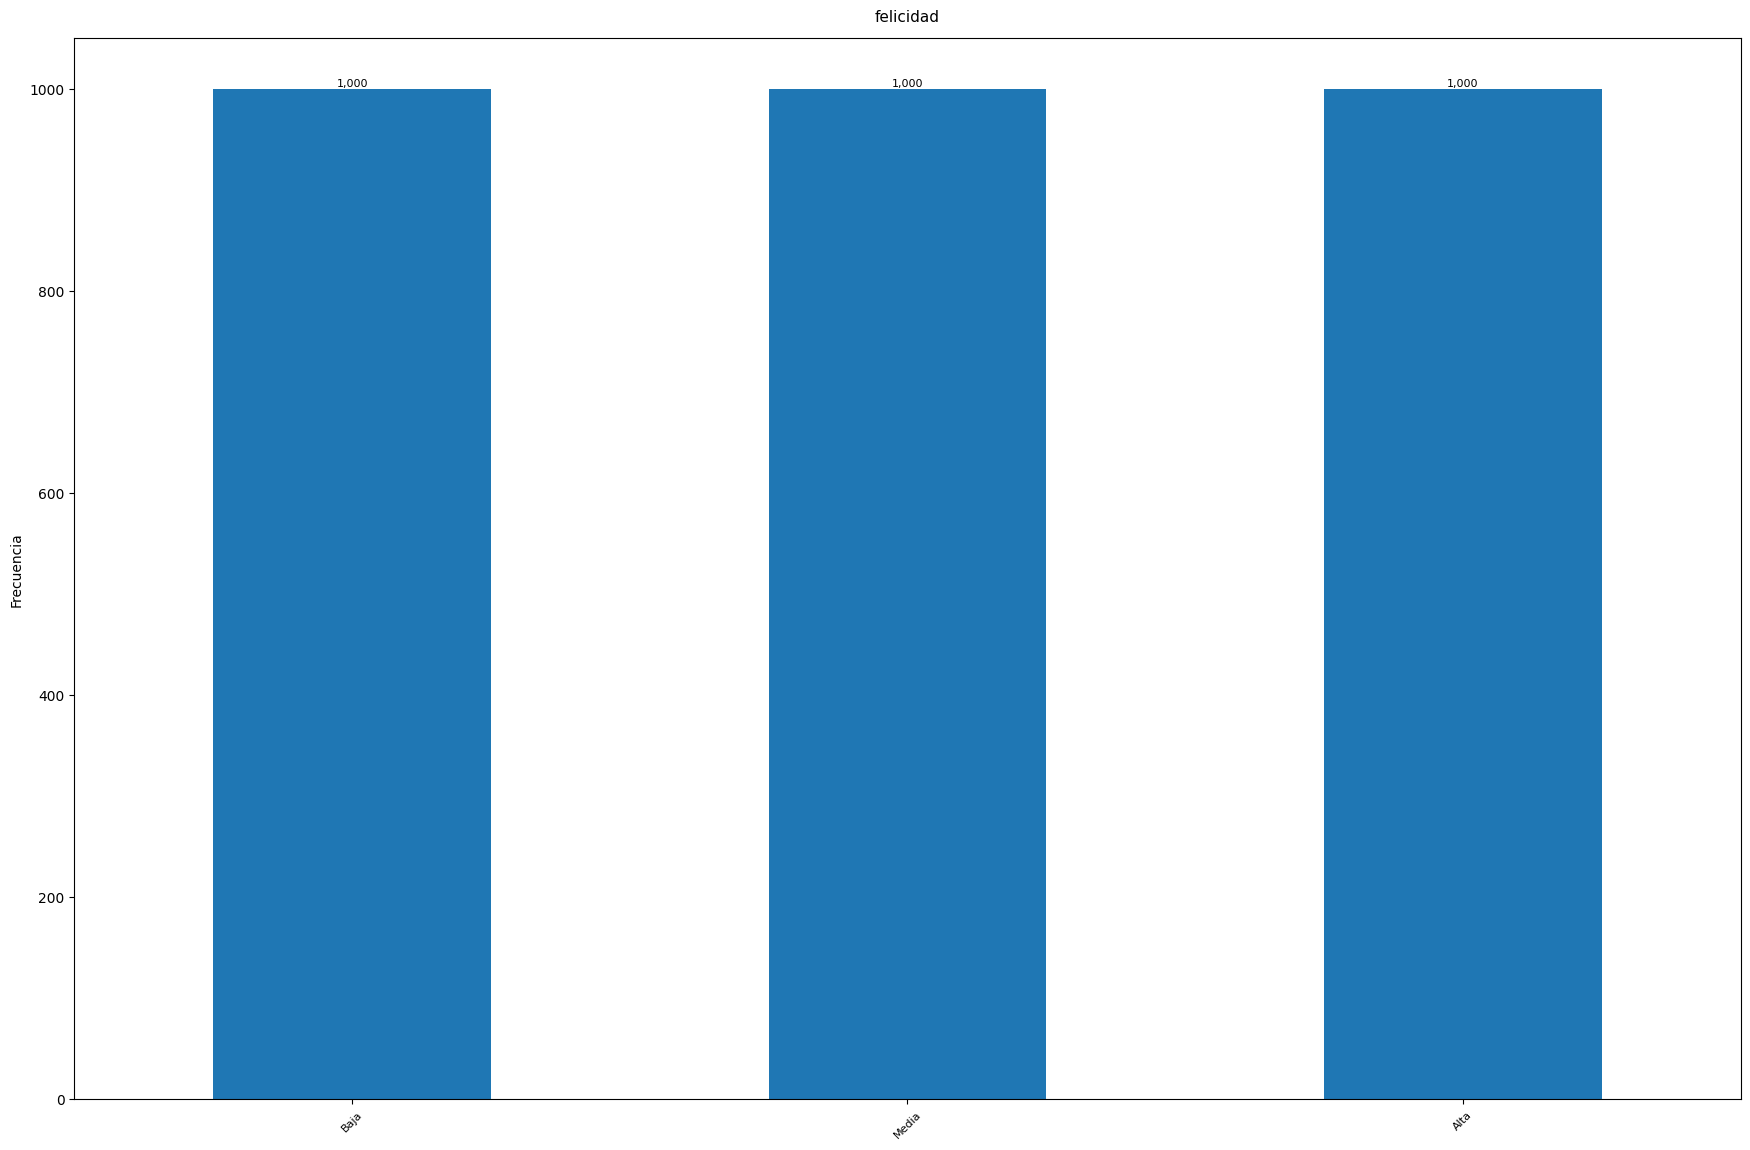

In [55]:
f_frecuencias_clases(datos)

# Desarrollo


## Datos de entrenamiento y datos de validación

In [56]:
particiones = f_particionar_datos(datos)
datos_entrenamiento = particiones["datos_entrenamiento"]
datos_validacion = particiones["datos_validacion"]
f_visualizar_head_tail_reducido(f_redondear(datos_entrenamiento))

,edad,salud,sueno,estres,...,estudio,autoestima,optimismo,felicidad
0,25,9,5,10,...,8,4,6,Baja
1,24,10,7,4,...,40,9,8,Alta
2,23,7,4,9,...,11,9,7,Baja
3,19,9,10,1,...,31,7,8,Alta
4,24,5,2,9,...,9,4,1,Baja
5,24,8,9,8,...,13,2,2,Media
6,...,...,...,...,...,...,...,...,...
7,22,7,5,5,...,11,6,4,Media
8,21,5,10,4,...,5,8,10,Alta
9,25,10,7,1,...,5,10,8,Alta


Datos de validción:


In [57]:
f_visualizar_head_tail_reducido(f_redondear(datos_validacion))

,edad,salud,sueno,estres,...,estudio,autoestima,optimismo,felicidad
0,18,5,8,3,...,21,4,3,Baja
1,22,2,1,3,...,33,8,2,Baja
2,28,9,5,6,...,5,5,9,Media
3,25,10,6,2,...,28,10,2,Alta
4,20,9,8,4,...,27,10,9,Media
5,23,9,10,1,...,18,9,9,Alta
6,...,...,...,...,...,...,...,...,...
7,19,7,1,10,...,13,1,2,Baja
8,21,1,9,4,...,6,7,3,Media
9,21,8,7,8,...,39,5,10,Media


## Estandarización de datos

La función *f_estandarizar_train_transf_valid()*, recibe los datos ya particionados, calcula medias y desviaciones únicamente con la los datos de entrenamiento, estandariza estos y aplica exactamente la misma transformación a los datos de validación y devuelve ambos conjuntos listos para construir modelos de clasificación.


In [58]:
resultado = f_estandarizar_train_transf_valid(
    datos_entrenamiento, datos_validacion, "felicidad")

datos_entrenamiento_std = (resultado["datos_entrenamiento"])

datos_validacion_std = (resultado["datos_validacion"])
f_visualizar_head_tail_reducido(f_redondear(datos_entrenamiento_std))

,edad,salud,sueno,estres,...,estudio,autoestima,optimismo,felicidad
0,0.26,0.81,-0.44,1.79,...,-1.55,-0.76,-0.13,Baja
1,-0.01,1.14,0.25,-0.26,...,1.5,0.95,0.57,Alta
2,-0.28,0.14,-0.78,1.45,...,-1.26,0.95,0.22,Baja
3,-1.36,0.81,1.28,-1.29,...,0.64,0.27,0.57,Alta
4,-0.01,-0.53,-1.47,1.45,...,-1.45,-0.76,-1.86,Baja
5,-0.01,0.47,0.94,1.11,...,-1.07,-1.44,-1.52,Media
6,...,...,...,...,...,...,...,...,...
7,-0.55,0.14,-0.44,0.08,...,-1.26,-0.08,-0.82,Media
8,-0.82,-0.53,1.28,-0.26,...,-1.83,0.61,1.26,Alta
9,0.26,1.14,0.25,-1.29,...,-1.83,1.29,0.57,Alta


In [59]:
f_visualizar_head_tail_reducido(f_redondear(datos_validacion_std))

,edad,salud,sueno,estres,...,estudio,autoestima,optimismo,felicidad
0,-1.63,-0.53,0.59,-0.61,...,-0.31,-0.76,-1.17,Baja
1,-0.55,-1.53,-1.81,-0.61,...,0.83,0.61,-1.52,Baja
2,1.06,0.81,-0.44,0.42,...,-1.83,-0.42,0.92,Media
3,0.26,1.14,-0.09,-0.95,...,0.36,1.29,-1.52,Alta
4,-1.09,0.81,0.59,-0.26,...,0.26,1.29,0.92,Media
5,-0.28,0.81,1.28,-1.29,...,-0.59,0.95,0.92,Alta
6,...,...,...,...,...,...,...,...,...
7,-1.36,0.14,-1.81,1.79,...,-1.07,-1.78,-1.52,Baja
8,-0.82,-1.87,0.94,-0.26,...,-1.74,0.27,-1.17,Media
9,-0.82,0.47,0.25,1.11,...,1.41,-0.42,1.26,Media


Ahora con los datos de entrenamiento estandarizados, el momento de construir todos los modelos de clasificación, *KNN*, *Ada Boost*, *Bayes*, estos se comparan y evalúan contra los modelos de clasificación *SVM* con kernel lineal, polinomial y radial; bosques aleatorios con criterios *Gini* y entropía; árboles de decisión con criterio *Gini* y entropía; Regresión Logística multinomial.  

Todos los modelos se construyen utilizando los datos de entrenamiento estandarizados.

Cada modelo se construye utilizando las funciones correspondientes previamente preparadas para esta tarea.

## Modelo KNN

Se construye modelo de clasificación vecinos cercanos *KNN* llamando la función *f_crear_modelo_KNN()*.

In [60]:
modelo_KNN = f_crear_modelo_KNN(datos_entrenamiento_std, "felicidad")
modelo_KNN


---------------------------------------
Modelo KNN construido correctamente
---------------------------------------
Observaciones : 2100
Variables     : 12
k             : 5
Escalamiento  : False
---------------------------------------



KNeighborsClassifier()

## Modelo Ada Boost

Se crea modelo de clasificación *Ada Boost* llamando la función *f_crear_modelo_Ada_Boost()*.



In [61]:
modelo_Ada_Boost = f_crear_modelo_Ada_Boost(datos_entrenamiento_std, "felicidad")
modelo_Ada_Boost


---------------------------------------
Modelo AdaBoost construido correctamente
---------------------------------------
Observaciones : 2100
Variables     : 12
Clasificadores: 50
Learning Rate : 1.0
Random State  : 123
---------------------------------------



AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=123),
                   random_state=123)

## Modelo clasificador de Bayes

Se construye el modelo clasificador de Bayes utilizando la función *f_crear_modelo_Bayes()*.



In [62]:
modelo_Bayes = f_crear_modelo_Bayes(datos_entrenamiento_std, "felicidad")
modelo_Bayes


---------------------------------------
Modelo Naïve Bayes construido correctamente
---------------------------------------
Observaciones : 2100
Variables     : 12
Clases        : 3
---------------------------------------



GaussianNB()

## Modelo SVM kernel lineal

Para un kernel lineal, *LinearSVC* es la implementación recomendada porque utiliza *LIBLINEAR*, siendo mucho más eficiente que *SVC(kernel="linear")*.

In [63]:
modelo_SVM_lineal = f_crear_modelo_SVM_lineal(datos_entrenamiento_std, "felicidad")
modelo_SVM_lineal


MODELO SVM LINEAL
Kernel              : Lineal
Implementación      : LinearSVC (LIBLINEAR)
Cost (C)            : 0.1
Número de clases    : 3
Iteraciones         : 7



LinearSVC(C=0.1, max_iter=10000, random_state=123)

## Modelo SVM kernel polinomial grado 2


In [40]:
modelo_SVM_poly2 = f_crear_modelo_SVM_polinomial(
    datos_entrenamiento_std,
    "felicidad"
)

modelo_SVM_poly2


MODELO SVM POLINOMIAL
Kernel               : Polinomial
Grado                : 2
Cost (C)             : 0.1
Coef0                : 1
Gamma                : scale
Número de clases     : 3
Vectores de soporte  : 679



SVC(C=0.1, coef0=1, degree=2, kernel='poly', probability=True, random_state=123)

## Modelo SVM kernel polinomial grado 3

In [41]:
modelo_SVM_poly3 = f_crear_modelo_SVM_polinomial(
    datos_entrenamiento_std,
    "felicidad", grado=3
)

modelo_SVM_poly3


MODELO SVM POLINOMIAL
Kernel               : Polinomial
Grado                : 3
Cost (C)             : 0.1
Coef0                : 1
Gamma                : scale
Número de clases     : 3
Vectores de soporte  : 566



SVC(C=0.1, coef0=1, kernel='poly', probability=True, random_state=123)

## Modelo SVM kernel radial

In [42]:
modelo_SVM_radial = f_crear_modelo_SVM_radial(
    datos_entrenamiento_std,
    "felicidad"
)
modelo_SVM_radial


MODELO SVM RADIAL
Kernel               : Radial (RBF)
Cost (C)             : 0.1
Gamma                : scale
Número de clases     : 3
Vectores de soporte  : 1280



SVC(C=0.1, probability=True, random_state=123)

## Modelo Bosques aleatorios Gini

In [43]:
modelo_RF_gini = f_construir_random_forest(datos_entrenamiento_std, "felicidad")
modelo_RF_gini


 RANDOM FOREST
Variable objetivo : felicidad
Número de clases  : 3
Variables         : 12
Árboles           : 500
Criterio          : gini
Observaciones     : 2100

Frecuencias:
Alta: 700
Baja: 701
Media: 699


RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=123)

## Modelo Bosques aleatorios entropía

In [44]:
modelo_RF_entropia = f_construir_random_forest(datos_entrenamiento_std,
                                               "felicidad",  criterion="entropy")
modelo_RF_entropia


 RANDOM FOREST
Variable objetivo : felicidad
Número de clases  : 3
Variables         : 12
Árboles           : 500
Criterio          : entropy
Observaciones     : 2100

Frecuencias:
Alta: 700
Baja: 701
Media: 699


RandomForestClassifier(criterion='entropy', n_estimators=500, n_jobs=-1,
                       random_state=123)

## Modelo árboles de decision criterio Gini



In [45]:
modelo_AC_gini= f_construir_arbol_clasificacion(
    datos_entrenamiento_std,
    "felicidad",
    criterion="gini"
)


 ÁRBOL DE CLASIFICACIÓN
Variable objetivo : felicidad
Número clases     : 3
Variables         : 12
Criterio          : gini
Observaciones     : 2100

Frecuencia de clases
Alta: 700
Baja: 701
Media: 699


## Modelo árboles de decisión criterio entropía


In [46]:
modelo_AC_entropia = f_construir_arbol_clasificacion(
    datos_entrenamiento_std,
    "felicidad",
    criterion="entropy"
)


 ÁRBOL DE CLASIFICACIÓN
Variable objetivo : felicidad
Número clases     : 3
Variables         : 12
Criterio          : entropy
Observaciones     : 2100

Frecuencia de clases
Alta: 700
Baja: 701
Media: 699


## Modelos regresión logística multinomial

In [47]:
modelo_RLM = f_crear_modelo_regresion_logistica(
    datos_entrenamiento_std,
    "felicidad",
    tipo="multinomial")


 REGRESIÓN LOGÍSTICA 
Tipo               : multinomial
Balanceo           : ninguno
Variable objetivo  : felicidad
Número de clases   : 3

Frecuencias originales:
{'Baja': 701, 'Alta': 700, 'Media': 699}

Frecuencias entrenamiento:
{'Baja': 701, 'Alta': 700, 'Media': 699}

Observaciones usadas: 2100


## Evaluación de modelos

Se evalúan todos los modelos de clasificación construidos usando los datos de validación estandarizados; se construye la matriz de confusión de las predicciones de cada modelos y se extraen los estadísticos que se presentan resumidos en modo consola.




In [48]:
evaluacion = f_evaluacion(
    modelos=[modelo_KNN, modelo_Ada_Boost, modelo_Bayes,
             modelo_SVM_lineal, modelo_SVM_poly2,
             modelo_SVM_poly3, modelo_SVM_radial,
        modelo_AC_gini, modelo_AC_entropia,
             modelo_RF_gini, modelo_RF_entropia, modelo_RLM],
    datos_validacion=[datos_validacion_std, datos_validacion_std, datos_validacion_std,
                      datos_validacion_std, datos_validacion_std,
        datos_validacion_std, datos_validacion_std,
        datos_validacion_std, datos_validacion_std,
        datos_validacion_std, datos_validacion_std,
        datos_validacion_std],
    variable_dependiente = "felicidad",
    nombres_modelos=["KNN", "Ada Boost", "Bayes",
                     "SVM Lineal", "SVM Poly2",
                     "SVM Poly3", "SVM Radial",
                     "Arboles Gini", "Arboles entropía",
        "Bosques aleatorios Gini", "Bosques aleatorios entropía",
        "Regresión Logística"]
)

evaluacion

,Modelo,Accuracy,Kappa,Precision,Recall,Sensitivity,Specificity,F1,Balanced_Accuracy,Balanceo
0,KNN,0.8733,0.8100,0.8735,0.8735,0.8735,0.9367,0.8714,0.9051,NaN
1,Ada Boost,0.7344,0.6015,0.8195,0.7343,0.7343,0.8670,0.7372,0.8007,NaN
2,Bayes,0.9600,0.9400,0.9607,0.9601,0.9601,0.9800,0.9599,0.9700,NaN
3,SVM Lineal,0.9478,0.9217,0.9539,0.9480,0.9480,0.9739,0.9473,0.9609,NaN
4,SVM Poly2,0.9822,0.9733,0.9827,0.9823,0.9823,0.9911,0.9822,0.9867,NaN
5,SVM Poly3,0.9756,0.9633,0.9758,0.9756,0.9756,0.9878,0.9755,0.9817,NaN
6,SVM Radial,0.9667,0.9500,0.9678,0.9667,0.9667,0.9834,0.9665,0.9750,NaN
7,Arboles Gini,0.7511,0.6267,0.7501,0.7512,0.7512,0.8755,0.7506,0.8134,NaN
8,Arboles entropía,0.7678,0.6517,0.7737,0.7679,0.7679,0.8839,0.7703,0.8259,NaN
9,Bosques aleatorios Gini,0.9300,0.8950,0.9300,0.9301,0.9301,0.9650,0.9298,0.9475,NaN


# Interpretación del caso

El caso de estudio cumple con el objetivo planteado de construir comparar y evaluar modelos de clasificación.

Los datos que se utilizaron fueron de un contexto de felicidad de estudiantes con ciertas características socio demográficas y/o académicas.

Se presentó la descripción estadística de los datos con valores similares a los presentados en *R*, las variables independientes fueron todas de tipo continuo y la variable dependiente felicidad es categórica.

Se hicieron las particiones con el *70%* de los datos para entrenamiento y *30%* para validación.

Se estandarizaron los datos de entrenamiento y con los mismos valores de media y desviación estándar, se normalizaron también los datos de validación cumpliendo con las criterios formales para escalar y/o estandarizar datos de entrenamiento y validación.

Se construyeron los modelos de clasificación *KNN*, *Ada Boost*, clasificador de *Bayes* como esencia de este caso de estudio y se compararon y evaluaron entre ellos mismos así como contra otros modelos como *SVM* con *kernel* lineal polinomial y radial; bosques aleatorios con criterios Gini y entropía; árboles de decisión también con criterios Gini y entropía además; el modelo de regresión logística multinomial.

De acuerdo a los resultados de la evaluación de calidad predictiva y de clasificación de todos los modelos, los modelos de *SVM* presentaron adecuada calidad predictiva seguidos del modelo clasificador de *Bayes*, sin embargo, para estos datos el modelo de regresión logística multinomial fue el mejor evaluado en comparación a todos los modelos de clasificación.

Los resultados obtenidos, fueron similares a los encontrados en el caso de estudio con *R* con estos mismos datos.
